<a href="https://colab.research.google.com/github/Angelenguems/Projet_IRM/blob/Loic_projet/analyse_exploratoire_et_qualite_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

pip install --upgrade keras tensorflow

# **Classification binaire des tumeurs cérébrales à partir d’images IRM**

##  **1. Introduction**


L’analyse des images médicales, notamment les images par résonance magnétique (IRM), joue un rôle essentiel dans le diagnostic des pathologies cérébrales. La détection des tumeurs cérébrales est une tâche complexe qui nécessite une expertise médicale approfondie et peut être sujette à des variations d’interprétation.

Dans ce contexte, l’utilisation des techniques d’apprentissage profond permet d’automatiser l’analyse des images et d’assister les professionnels de santé dans le processus de diagnostic.

L’objectif de ce projet est de développer un modèle de classification capable de distinguer automatiquement les images IRM contenant une tumeur (tumor) de celles n’en contenant pas (no_tumor). Pour cela, une approche basée sur le transfert d’apprentissage a été adoptée en utilisant le modèle pré-entraîné ResNet50.

Afin d’améliorer les performances du modèle, plusieurs techniques ont été mises en œuvre, notamment l’amélioration du contraste des images avec CLAHE, l’augmentation des données, le fine-tuning du modèle, ainsi que l’optimisation du seuil de décision. Enfin, une analyse d’interprétabilité a été réalisée à l’aide de Grad-CAM afin de visualiser les régions de l’image utilisées par le modèle pour prendre ses décisions.

## **2. Importation des bibliothèques**

In [2]:
# Manipulation de données
import os
import random
import numpy as np
import pandas as pd
import gdown
import zipfile
import shutil

# Gestion des chemins
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Traitement d'images
import cv2
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Métriques
from sklearn.metrics import (classification_report,confusion_matrix,precision_score,recall_score,f1_score,accuracy_score)

## **3. Chargement et organisation des données**
Dans cette section, le dataset est téléchargé, extrait, puis restructuré en un problème de classification binaire. Les trois classes tumorales (`glioma_tumor`, `meningioma_tumor` et `pituitary_tumor`) sont fusionnées dans une seule classe `tumor`, tandis que la classe `no_tumor` est conservée telle quelle. Une nouvelle arborescence de données est ensuite créée afin de faciliter l’entraînement du modèle.
### 3.1 téléchargement et extraction du dataset

In [3]:
file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"
output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall("/content/")

# Détection automatique du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = Path(f"/content/{possible_dirs[0]}")
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=40cc9b27-591b-4077-99b1-11c55912c0e5
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:00<00:00, 168MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


### 3.2 Réorganisation du dataset en classification binaire

In [4]:
src_root = DATA_PATH
dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]
tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
no_tumor_folder = "no_tumor"

# Suppression du dossier cible s'il existe déjà
if dst_root.exists():
    shutil.rmtree(dst_root)

# Création de l'arborescence binaire
for split in splits:
    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)
    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

def safe_copy(src_file: Path, dst_dir: Path):
    dst_file = dst_dir / src_file.name

    if dst_file.exists():
        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"

    shutil.copy2(src_file, dst_file)

# Fusion des classes tumorales
for split in splits:
    for cls in tumor_folders:
        cls_path = src_root / split / cls
        if cls_path.exists():
            for img in cls_path.rglob("*"):
                if img.is_file():
                    safe_copy(img, dst_root / split / "tumor")

    cls_path = src_root / split / no_tumor_folder
    if cls_path.exists():
        for img in cls_path.rglob("*"):
            if img.is_file():
                safe_copy(img, dst_root / split / "no_tumor")

print("Fusion binaire terminée.")
print("Dossier source :", src_root)
print("Classes Training :", os.listdir(dst_root / "Training"))
print("Classes Testing  :", os.listdir(dst_root / "Testing"))

Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri
Classes Training : ['tumor', 'no_tumor']
Classes Testing  : ['tumor', 'no_tumor']


### 3.3 Vérification du nombre d’images

In [5]:
print("Nombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


### 3.4 Chargement des datasets TensorFlow

In [6]:
train_dir = "/content/Binary/Training"
test_dir = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))
print("Classes test  :", os.listdir(test_dir))

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


## **4. Analyse exploratoire et qualité des images**

Avant l’entraînement du modèle, une vérification de la qualité des images est effectuée. Cette étape permet d’identifier d’éventuelles images corrompues ainsi que d’examiner la cohérence du dataset. Une telle démarche contribue à fiabiliser le pipeline d’apprentissage.

### 4.1 Suppression des images corrompues

In [7]:
train_dir = Path("/content/Binary/Training")
test_dir = Path("/content/Binary/Testing")

def remove_corrupted_images(folder: Path):
    removed = 0

    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1

    return removed

removed_train = remove_corrupted_images(train_dir)
removed_test = remove_corrupted_images(test_dir)

print("\nNettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


In [8]:
print("Nombre d'images Training/tumor    :", len(list((train_dir / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((train_dir / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((test_dir / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((test_dir / "no_tumor").glob("*"))))

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


### 4.3 Visualisation de quelques images

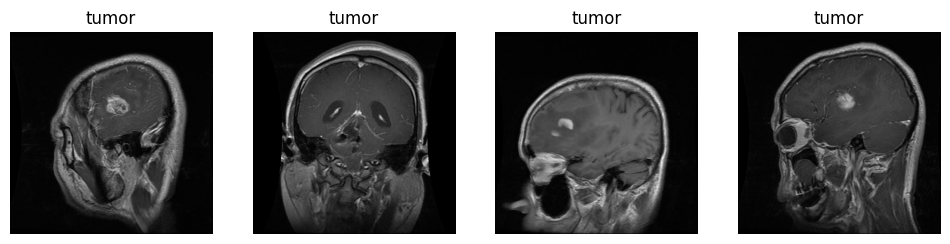

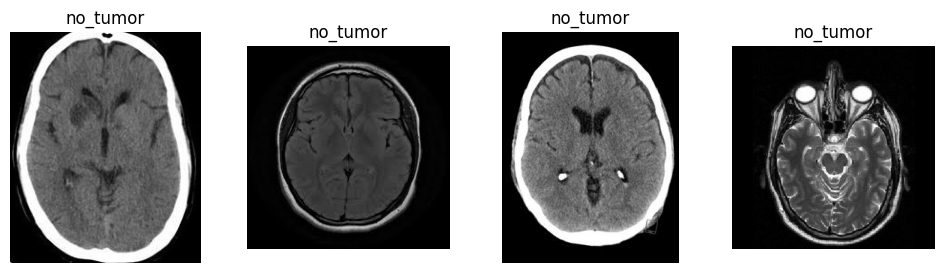

In [9]:
def show_sample_images(folder, title, n=4):
    image_paths = list(folder.glob("*"))
    selected_images = random.sample(image_paths, min(n, len(image_paths)))

    plt.figure(figsize=(12, 3))

    for i, img_path in enumerate(selected_images, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(selected_images), i)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.show()

show_sample_images(train_dir / "tumor", "tumor")
show_sample_images(train_dir / "no_tumor", "no_tumor")